## Step 1: Install & Import Libraries

In [8]:
import librosa
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

## Step 2: Feature Extraction (MFCC)

In [7]:
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

def extract_mfcc(file_path, n_mfcc=40):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc.T, axis=0)

In [20]:
data_path = "data"
features = []
labels = []

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith(".wav"):
            parts = file.split("-")
            emotion_code = parts[2]
            emotion = emotion_map.get(emotion_code)
            if emotion:
                file_path = os.path.join(root, file)
                mfcc = extract_mfcc(file_path)
                features.append(mfcc)
                labels.append(emotion)

df = pd.DataFrame(features)
df['label'] = labels
df.to_csv("features.csv", index=False)
print("Done! Total samples:", len(df))
df.head()

Done! Total samples: 1440


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,label
0,-670.195435,65.063850,0.888954,14.715979,9.182164,0.660575,-3.846836,-3.583946,-12.959006,-3.300133,...,-2.504727,-3.151507,-2.190899,-3.801760,-1.813088,-1.261222,-2.144954,-4.152173,-1.779615,neutral
1,-660.230347,63.325817,-2.630457,17.983355,9.407703,-0.981498,-2.324697,-6.848032,-14.133670,-2.200332,...,-3.113372,-2.556752,-2.935112,-3.654963,-0.988048,-1.499825,-3.617126,-3.751694,-2.730914,neutral
2,-661.964478,66.655869,-0.932158,14.899042,5.324703,0.474343,-3.346651,-7.102525,-12.873403,-5.088379,...,-2.643650,-2.937168,-2.361648,-3.345104,-2.426059,-1.460013,-3.281309,-4.208614,-2.726206,neutral
3,-657.722351,65.035187,3.148672,15.666511,7.582657,2.628087,-1.850069,-7.477578,-11.976265,-4.458463,...,-2.849612,-3.591488,-3.104016,-3.495707,-1.628411,-1.304878,-3.032794,-3.973964,-3.861779,neutral
4,-694.579590,72.531715,3.104562,17.112118,9.077338,1.836257,-4.146086,-4.797151,-11.764124,-5.925480,...,-1.405873,-2.290346,-2.879143,-2.069092,-0.544464,-2.073816,-2.080611,-4.573941,-3.246941,calm


## Step 3: Prepare Data for Training

In [13]:
df = pd.read_csv("features.csv")
X = df.drop("label", axis=1).values
y = df["label"].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", le.classes_)

Train shape: (1152, 40)
Test shape: (288, 40)
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


## Step 4: Build & Train the Model

In [14]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\User\Desktop\Speech_Emotion_Recognization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,168 (203.78 KB)

 Trainable params: 52,168 (203.78 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                     validation_data=(X_test, y_test))

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1745 - loss: 2.0203 - val_accuracy: 0.2326 - val_loss: 1.9029
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2969 - loss: 1.8280 - val_accuracy: 0.3438 - val_loss: 1.7461
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3333 - loss: 1.7175 - val_accuracy: 0.3785 - val_loss: 1.6276
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4054 - loss: 1.5780 - val_accuracy: 0.4028 - val_loss: 1.5265
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4444 - loss: 1.4837 - val_accuracy: 0.4201 - val_loss: 1.4596
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4974 - loss: 1.3710 - val_accuracy: 0.4514 - val_loss: 1.3721
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5156 - loss: 1.3047 - val_accuracy: 0.5208 - val_loss: 1.3010
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5720 - loss: 1.1982 - val_accuracy: 0.5069 - val_loss

## Step 5: Evaluate the Model

In [16]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

model.save("emotion_model.h5")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6701 - loss: 1.0623 


Test Accuracy: 67.01%


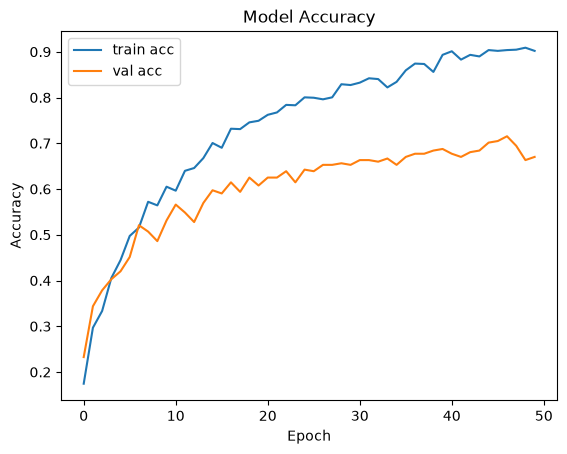

In [17]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.savefig("accuracy_plot.png")
plt.show()

## Step 6: Predict Emotion from a New Audio File

In [18]:
def predict_emotion(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0).reshape(1, -1)
    mfcc_scaled = scaler.transform(mfcc_mean)
    prediction = model.predict(mfcc_scaled)
    predicted_label = le.inverse_transform([np.argmax(prediction)])
    return predicted_label[0]

#EXAMPLE USAGE:
result = predict_emotion(r"data\audio_speech_actors_01-24\Actor_08\03-01-01-01-02-02-08.wav")
print("Predicted Emotion:", result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Predicted Emotion: disgust


In [ ]:
result = predict_emotion("data/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav")
print("Predicted Emotion:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Emotion: neutral


In [19]:
result = predict_emotion("data/audio_speech_actors_01-24/Actor_17/03-01-02-01-01-01-17.wav")
print(" Predicted Emotion:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
 Predicted Emotion: calm
